# Variables del Entorno

In [79]:
# [Librerías importadas]

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import rioxarray
from shapely.geometry import Point
import warnings
import tempfile
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")


In [ ]:
# [Funciones]
def mapa_climatico_anual(
    rutas: dict,
    shapefile_path: str,
    variable_nc: str,
    nombre_columna: str,
    etiqueta_colorbar: str,
    titulo_general: str,
    unidad_conversion=None,
    cmap: str = "YlGnBu",
    vecinos: int = 3,
    guardar_raster: bool = False,
    carpeta_salida: str = "resultados"
):
    """
    Genera mapas anuales promedio por municipio para una variable climática
    (clasificación por cuantiles k=5), rellena valores faltantes por vecinos
    y guarda automáticamente un CSV con los promedios anuales.
    """

    # ------------------------------------------------------------
    # 1️⃣ Cargar shapefile base (filtrar Atlántico)
    # ------------------------------------------------------------
    gdf_base = gpd.read_file(shapefile_path, encoding="utf-8")
    if "mpio_cnmbr" in gdf_base.columns:
        gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
    gdf_base = gdf_base[gdf_base['dpto_cnmbr'].str.upper() == 'ATLÁNTICO']

    resultados = []

    # ------------------------------------------------------------
    # 2️⃣ Crear figura
    # ------------------------------------------------------------
    n = len(rutas)
    filas = 2
    columnas = int(np.ceil(n / filas))
    fig, axes = plt.subplots(filas, columnas, figsize=(4 * columnas, 4 * filas))
    axes = axes.flatten()

    # ------------------------------------------------------------
    # 3️⃣ Procesar cada año
    # ------------------------------------------------------------
    for i, (anio, ruta) in enumerate(rutas.items()):
        print(f"📆 Procesando {anio}...")

        ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")
        var = ds[variable_nc].rio.write_crs("EPSG:4326")

        # --- Conversión automática ---
        data = var
        if "Temperature" in variable_nc:
            data = data - 273.15  # Kelvin → °C
            if cmap == "YlGnBu":
                cmap = "RdYlBu_r"
        elif "Humidity" in variable_nc or "Humedad" in variable_nc:
            if data.max() <= 1:
                data = data * 100  # 0–1 → %
            cmap = "YlGnBu"

        # --- Conversión personalizada ---
        if unidad_conversion is not None:
            data = unidad_conversion(data)

        # --- Promedio anual ---
        promedio_anual = data.mean(dim="time", skipna=True)

        # --- Guardar raster temporal ---
        if guardar_raster and carpeta_salida:
            os.makedirs(carpeta_salida, exist_ok=True)
            raster_out = os.path.join(carpeta_salida, f"{nombre_columna}_{anio}.tif")
            promedio_anual.rio.to_raster(raster_out)
        else:
            tmp = tempfile.NamedTemporaryFile(suffix=".tif", delete=False)
            raster_out = tmp.name
            promedio_anual.rio.to_raster(raster_out)
            tmp.close()

        # --- Estadísticas zonales ---
        gdf = gdf_base.copy()
        stats = zonal_stats(gdf, raster_out, stats="mean", nodata=np.nan)
        gdf[nombre_columna] = [s["mean"] for s in stats]

        # --- Rellenar faltantes con promedio de vecinos ---
        gdf["centroide"] = gdf.geometry.centroid
        gdf_con_datos = gdf.dropna(subset=[nombre_columna])
        gdf_sin_datos = gdf[gdf[nombre_columna].isna()]

        for idx, row in gdf_sin_datos.iterrows():
            gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
            vecinos_cercanos = gdf_con_datos.nsmallest(vecinos, "dist")
            gdf.at[idx, nombre_columna] = vecinos_cercanos[nombre_columna].mean()

        gdf.drop(columns="centroide", inplace=True)

        # --- Guardar resultado para CSV ---
        gdf["año"] = anio
        resultados.append(gdf[["municipio", "año", nombre_columna]])

        # --- Graficar ---
        ax = axes[i]
        gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
        gdf.plot(
            column=nombre_columna,
            cmap=cmap,
            scheme="Quantiles",
            k=5,
            edgecolor="black",
            linewidth=0.5,
            ax=ax,
            missing_kwds={"color": "white", "hatch": "///", "label": "Sin datos"}
        )

        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=plt.Normalize(vmin=gdf[nombre_columna].min(), vmax=gdf[nombre_columna].max())
        )
        sm._A = []
        cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
        cbar.set_label(etiqueta_colorbar, fontsize=9)

        ax.set_title(f"{anio}", fontsize=11)
        ax.axis("off")

        # Limpiar archivo temporal
        if not guardar_raster:
            os.remove(raster_out)

    # ------------------------------------------------------------
    # 4️⃣ Guardar CSV final
    # ------------------------------------------------------------
    df_final = pd.concat(resultados, ignore_index=True)
    os.makedirs(carpeta_salida, exist_ok=True)
    csv_path = os.path.join(carpeta_salida, f"{nombre_columna}_anual.csv")
    df_final.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"✅ CSV guardado: {csv_path}")

    # ------------------------------------------------------------
    # 5️⃣ Mostrar figura final
    # ------------------------------------------------------------
    plt.suptitle(titulo_general, fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return df_final


## Distribución Espacial

### Precipitación

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\precipitacion_anual.csv


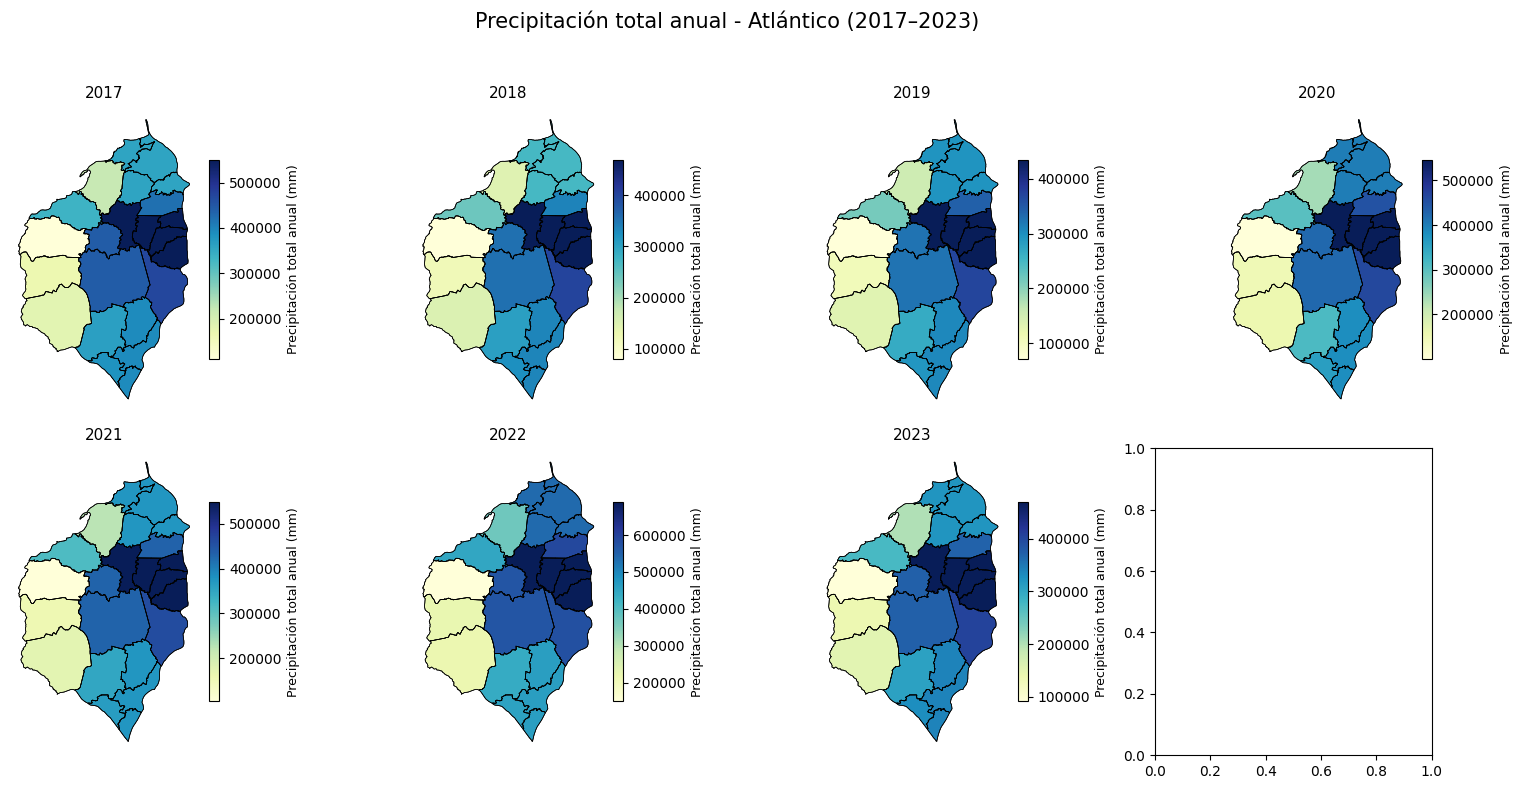

In [66]:
rutas_prec = {
   
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019",
    2020: r"C:\Dengue\Datos Clima\precipitacion_atl_2020",
    2021: r"C:\Dengue\Datos Clima\precipitacion_atl_2021",
    2022: r"C:\Dengue\Datos Clima\precipitacion_atl_2022",
    2023: r"C:\Dengue\Datos Clima\precipitacion_atl_2023"
}


df_precipitacion = mapa_climatico_anual(
    rutas=rutas_prec,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Precipitation_Flux",
    nombre_columna="precipitacion",
    etiqueta_colorbar="Precipitación total anual (mm)",
    titulo_general="Precipitación total anual - Atlántico (2017–2023)",
    # conversión de kg/m²/s a mm/día, si tus datos vienen en flujo
    unidad_conversion=lambda x: x * 86400,
    carpeta_salida="resultados"
)



### Humedad Relativa

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\humedad_anual.csv


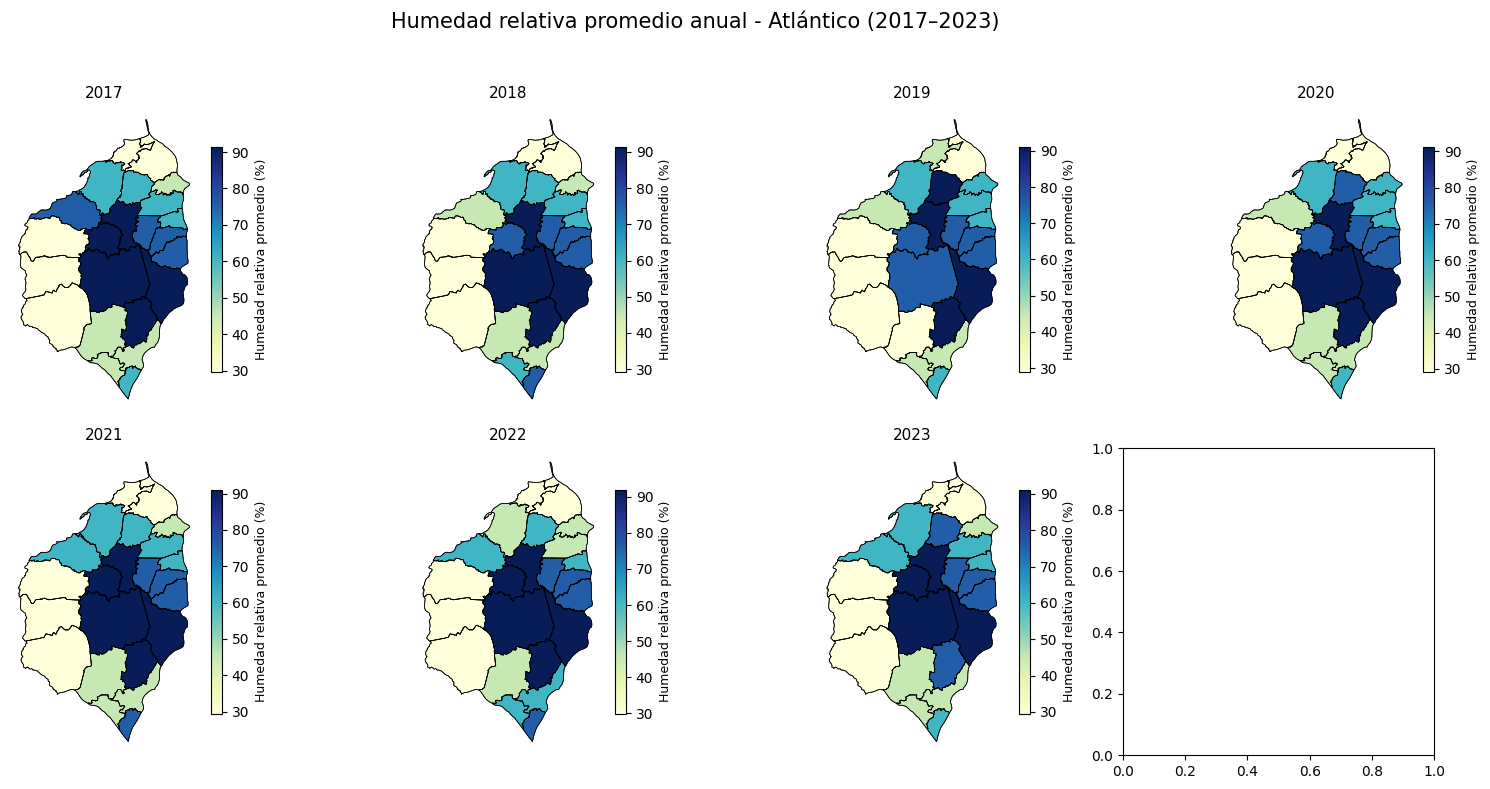

In [68]:
rutas_hum = {
    2017: r"C:\Dengue\Datos Clima\humedad_atl_2017",
    2018: r"C:\Dengue\Datos Clima\humedad_atl_2018",
    2019: r"C:\Dengue\Datos Clima\humedad_atl_2019",
    2020: r"C:\Dengue\Datos Clima\humedad_atl_2020",
    2021: r"C:\Dengue\Datos Clima\humedad_atl_2021",
    2022: r"C:\Dengue\Datos Clima\humedad_atl_2022",
    2023: r"C:\Dengue\Datos Clima\humedad_atl_2023"
}

df_humedad = mapa_climatico_anual(
    rutas=rutas_hum,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Relative_Humidity_2m_06h",
    nombre_columna="humedad",
    etiqueta_colorbar="Humedad relativa promedio (%)",
    titulo_general="Humedad relativa promedio anual - Atlántico (2017–2023)",
    unidad_conversion=None,
    carpeta_salida="resultados"
)



### Temperatura

#### Maxima

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\temp_max_anual.csv


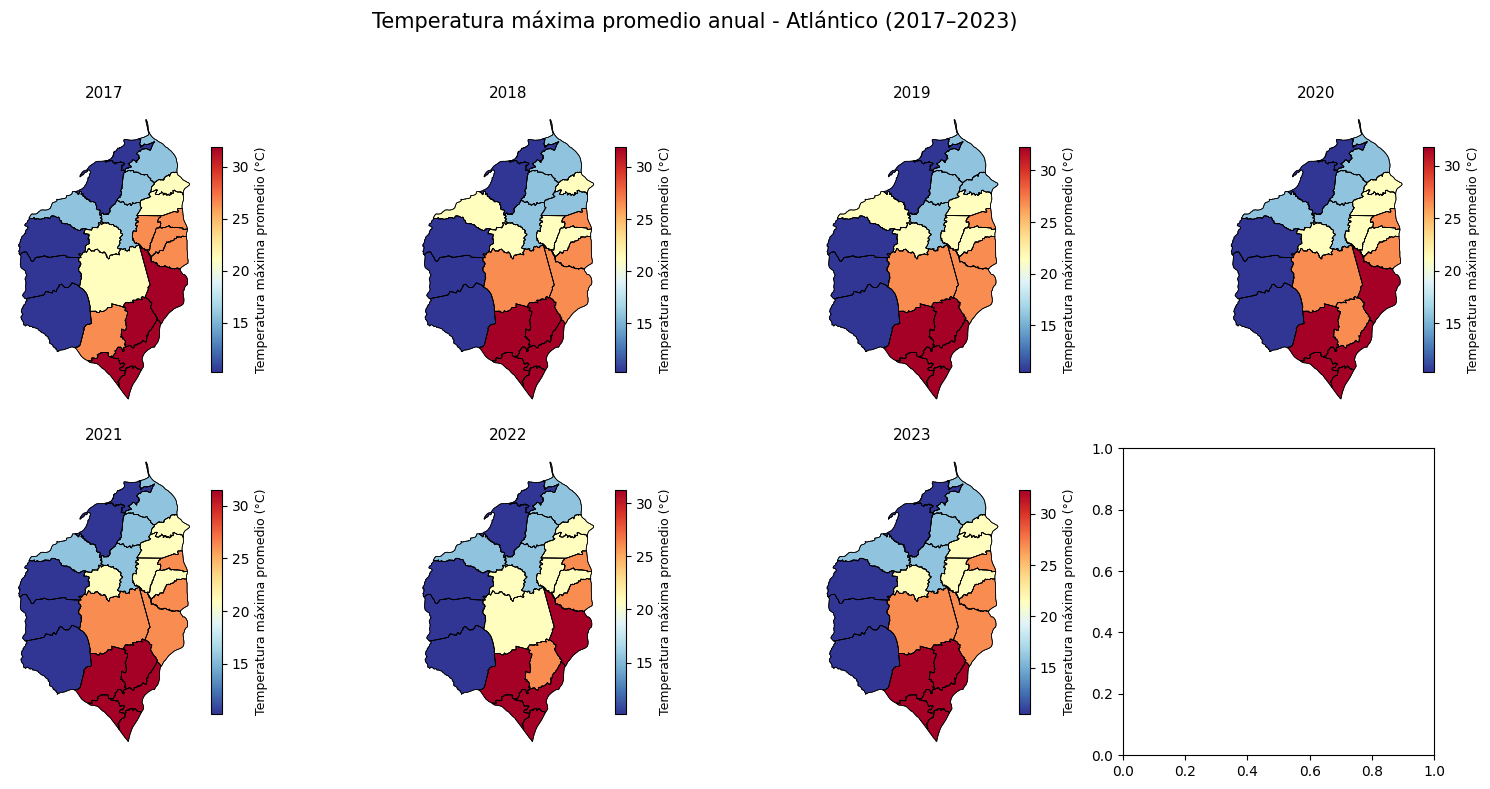

In [69]:
rutas_temp_max = {
    2017: r"C:\Dengue\Datos Clima\temp_max_atl_2017",
    2018: r"C:\Dengue\Datos Clima\temp_max_atl_2018",
    2019: r"C:\Dengue\Datos Clima\temp_max_atl_2019",
    2020: r"C:\Dengue\Datos Clima\temp_max_atl_2020",
    2021: r"C:\Dengue\Datos Clima\temp_max_atl_2021",
    2022: r"C:\Dengue\Datos Clima\temp_max_atl_2022",
    2023: r"C:\Dengue\Datos Clima\temp_max_atl_2023"
}
df_tmax = mapa_climatico_anual(
    rutas=rutas_temp_max,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Max_24h",
    nombre_columna="temp_max",
    etiqueta_colorbar="Temperatura máxima promedio (°C)",
    titulo_general="Temperatura máxima promedio anual - Atlántico (2017–2023)",
    unidad_conversion=None,  # ya se convierte automáticamente
    carpeta_salida="resultados"
)


#### Minima

📆 Procesando 2017...
📆 Procesando 2018...
📆 Procesando 2019...
📆 Procesando 2020...
📆 Procesando 2021...
📆 Procesando 2022...
📆 Procesando 2023...
✅ CSV guardado: resultados\temp_min_anual.csv


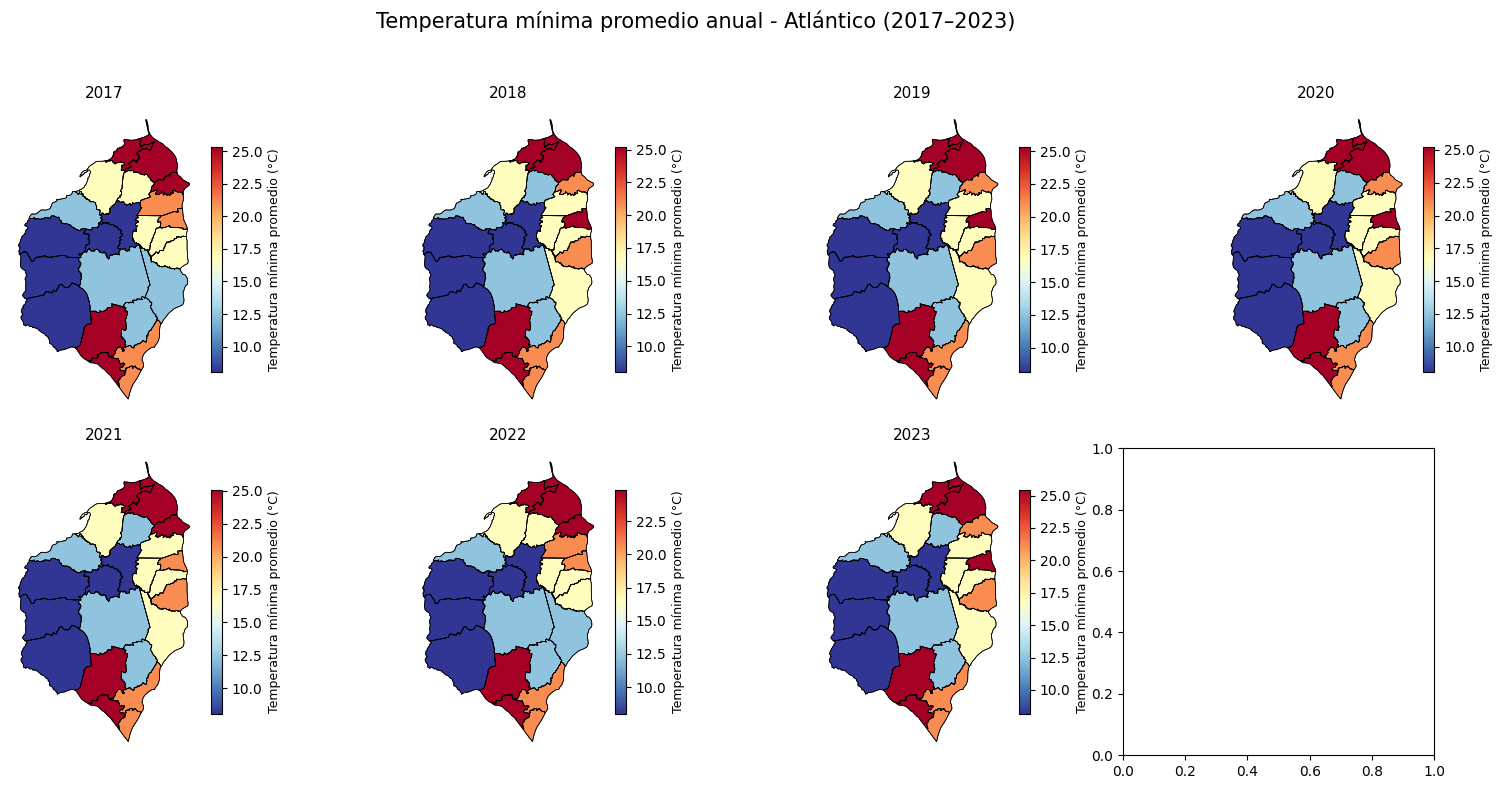

In [70]:
rutas_temp_min = {
    2017: r"C:\Dengue\Datos Clima\temp_min_atl_2017",
    2018: r"C:\Dengue\Datos Clima\temp_min_atl_2018",
    2019: r"C:\Dengue\Datos Clima\temp_min_atl_2019",
    2020: r"C:\Dengue\Datos Clima\temp_min_atl_2020",
    2021: r"C:\Dengue\Datos Clima\temp_min_atl_2021",
    2022: r"C:\Dengue\Datos Clima\temp_min_atl_2022",
    2023: r"C:\Dengue\Datos Clima\temp_min_atl_2023"
}

df_tmin = mapa_climatico_anual(
    rutas=rutas_temp_min,  # diccionario con las rutas de los archivos .nc por año
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Min_24h",
    nombre_columna="temp_min",
    etiqueta_colorbar="Temperatura mínima promedio (°C)",
    titulo_general="Temperatura mínima promedio anual - Atlántico (2017–2023)",
    unidad_conversion=None,
    carpeta_salida="resultados"
)



### Distancia al río mas cercano

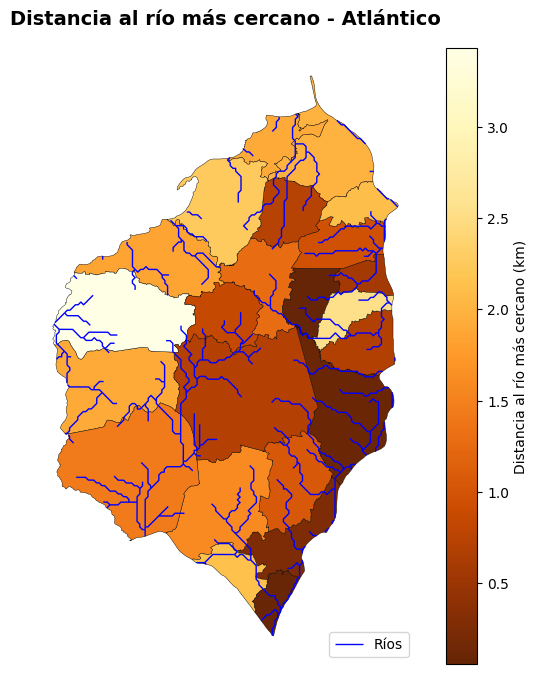

In [57]:
gdf_mpios = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_rio.shp")
rios_clip = gpd.read_file(r"C:\Dengue\Datos Clima\HydroRIVERS_Atlantico.shp")

# --- Asegurar CRS proyectado (para medir en metros) ---
gdf_mpios = gdf_mpios.to_crs(3116)  # EPSG:3116 = Colombia Bogotá / MAGNA-SIRGAS
rios_clip = rios_clip.to_crs(3116)

# --- Crear figura y eje ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- Graficar municipios con la distancia al río ---
gdf_mpios.plot(
    column='dist_rio_1',
    cmap='YlOrBr_r',  # escala invertida: oscuro = más cerca
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': "Distancia al río más cercano (km)",
        'orientation': "vertical"
    },
    ax=ax
)

# --- Graficar ríos encima ---
rios_clip.plot(ax=ax, color='blue', linewidth=1, label='Ríos')

# --- Personalizar ---
ax.set_title("Distancia al río más cercano - Atlántico", fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(loc='lower right')

plt.show()


### Distancia al cuerpo de agua más cercano

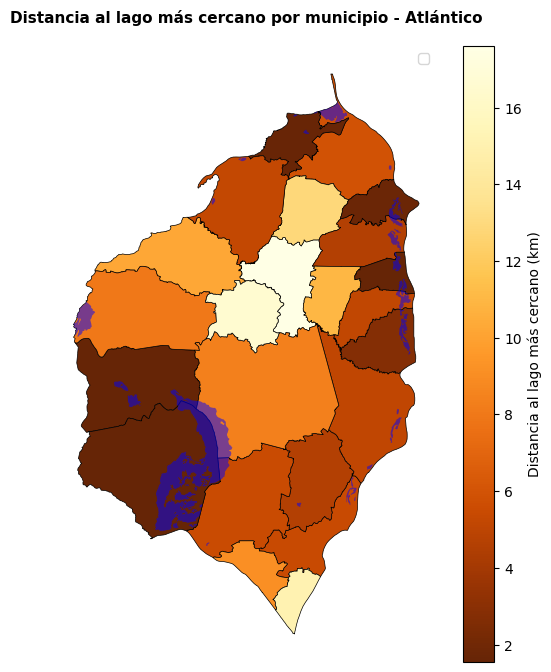

In [75]:
municipios_utm = gpd.read_file(r"C:\Dengue\Datos Clima\covariable_distancia_lago.shp").to_crs(3116)
lagos_utm = gpd.read_file(r"C:\Dengue\Datos Clima\HydroLAKES_Atlantico.shp").to_crs(3116)

# ------------------------------------------------------------
# 5️⃣ Visualización
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 8))
municipios_utm.plot(
    column="dist_lag_1",
    cmap="YlOrBr_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Distancia al lago más cercano (km)"},
    ax=ax
)
lagos_utm.plot(ax=ax, color="blue", alpha=0.5, label="Lagos y embalses")

ax.set_title("Distancia al lago más cercano por municipio - Atlántico", fontsize=11, weight="bold")
ax.axis("off")
ax.legend()
plt.show()

## Descriptivo

In [80]:
# Cargar los datos
df = pd.read_csv("datos clima/datos_climaticos_completos.csv")


In [81]:
# Ajustes básicos
df["municipio"] = df["municipio"].str.title()  # Mejor formato para visualización
print("Dimensiones:", df.shape)
display(df.head())

# Descripción general
print("\n📊 Estadísticas generales:")
display(df.describe().T)

Dimensiones: (161, 8)


,municipio,año,temp_max,temp_min,humedad,precipitacion,dist_rio_1,dist_lag_1
0,Baranoa,2017,30.448818,23.998936,91.041267,550048.439013,1.275987,17.603675
1,Baranoa,2018,30.370150,23.930357,90.869202,469218.278412,1.275987,17.603675
2,Baranoa,2019,30.610964,24.197859,90.464691,434414.467096,1.275987,17.603675
3,Baranoa,2020,30.321980,24.007429,90.616714,546243.935162,1.275987,17.603675
4,Baranoa,2021,30.161251,23.827612,90.452652,547501.413585,1.275987,17.603675



📊 Estadísticas generales:


,count,mean,std,min,25%,50%,75%,max
año,161.0,2020.000000,2.006240,2017.000000,2018.000000,2020.000000,2022.000000,2023.000000
temp_max,161.0,28.694303,5.869260,10.162036,30.084091,30.716817,31.354534,32.356838
temp_min,161.0,22.786975,4.689615,7.981450,24.148674,24.494722,24.781071,25.459774
humedad,161.0,82.773320,17.136223,29.061325,88.136711,89.141668,89.882848,91.962898
precipitacion,161.0,372242.294760,137320.724915,71449.249063,300657.836025,373539.155241,463243.659355,689034.081941
dist_rio_1,161.0,1.326783,0.873050,0.058358,0.692781,1.275987,1.991481,3.430433
dist_lag_1,161.0,7.001841,4.805495,1.544053,2.759988,5.433398,10.258566,17.603675


In [ ]:
variables = ["temp_max", "temp_min", "humedad", "precipitacion"]

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual global
sns.set_theme(style="whitegrid", font_scale=1.1)

# ------------------------------------------------------------
# 1️⃣ Boxplots horizontales (en grilla 2x2)
# ------------------------------------------------------------
def boxplot_variables(df, variables):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    
    for ax, var in zip(axes, variables):
        sns.boxplot(x=df[var], ax=ax, color="#8ecae6", orient="h", fliersize=3)
        ax.set_title(f"Distribución de {var}", fontsize=11, weight="bold")
        ax.set_xlabel(var)
        ax.set_ylabel("")
    
    # Si hay menos de 4 variables, ocultar los ejes vacíos
    for ax in axes[len(variables):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Ejemplo
# boxplot_variables(df, ["temp_max", "temp_min", "humedad", "precipitacion"])


# ------------------------------------------------------------
# 2️⃣ Histogramas con escala logarítmica (en grilla 2x2)
# ------------------------------------------------------------
def hist_variables(df, variables, bins=25):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    
    for ax, var in zip(axes, variables):
        sns.histplot(df[var], bins=bins, kde=True, ax=ax, color="#219ebc")
        ax.set_title(f"Histograma de {var}", fontsize=11, weight="bold")
        ax.set_xlabel(var)
        ax.set_ylabel("Frecuencia (log)")
        ax.set_yscale("log")  # Escala logarítmica en el eje Y
    
    for ax in axes[len(variables):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Ejemplo
# hist_variables(df, ["temp_max", "temp_min", "humedad", "precipitacion"])


# ------------------------------------------------------------
# 3️⃣ Evolución temporal de las variables (grilla 2x2)
# ------------------------------------------------------------
def evolucion_anual(df, variables):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, var in zip(axes, variables):
        temp = df.groupby("año")[var].mean().reset_index()
        sns.lineplot(data=temp, x="año", y=var, marker="o", ax=ax, color="#023047")
        ax.set_title(f"Evolución anual de {var}", fontsize=11, weight="bold")
        ax.set_xlabel("Año")
        ax.set_ylabel(var)
        ax.grid(alpha=0.3, linestyle="--")

    for ax in axes[len(variables):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Ejemplo
# evolucion_anual(df, ["temp_max", "temp_min", "humedad", "precipitacion"])


# ------------------------------------------------------------
# 4️⃣ Correlaciones (solo una figura)
# ------------------------------------------------------------
def matriz_correlacion(df, variables):
    corr = df[variables].corr()
    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matriz de correlación", fontsize=13, weight="bold")
    plt.show()


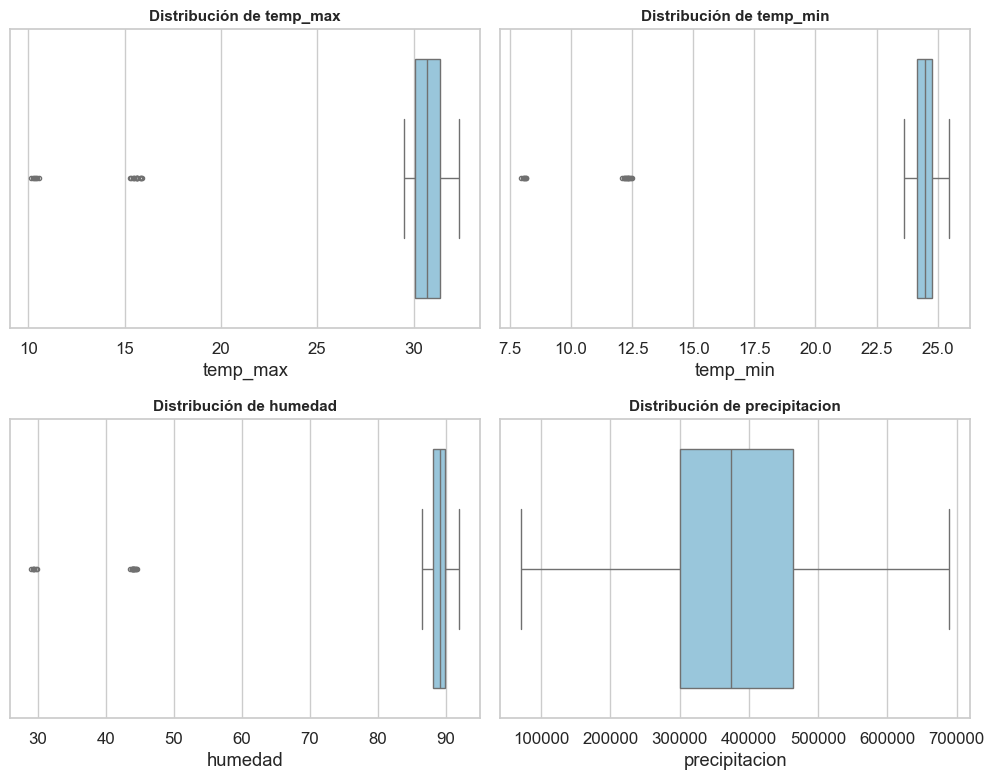

In [92]:
boxplot_variables(df, variables)




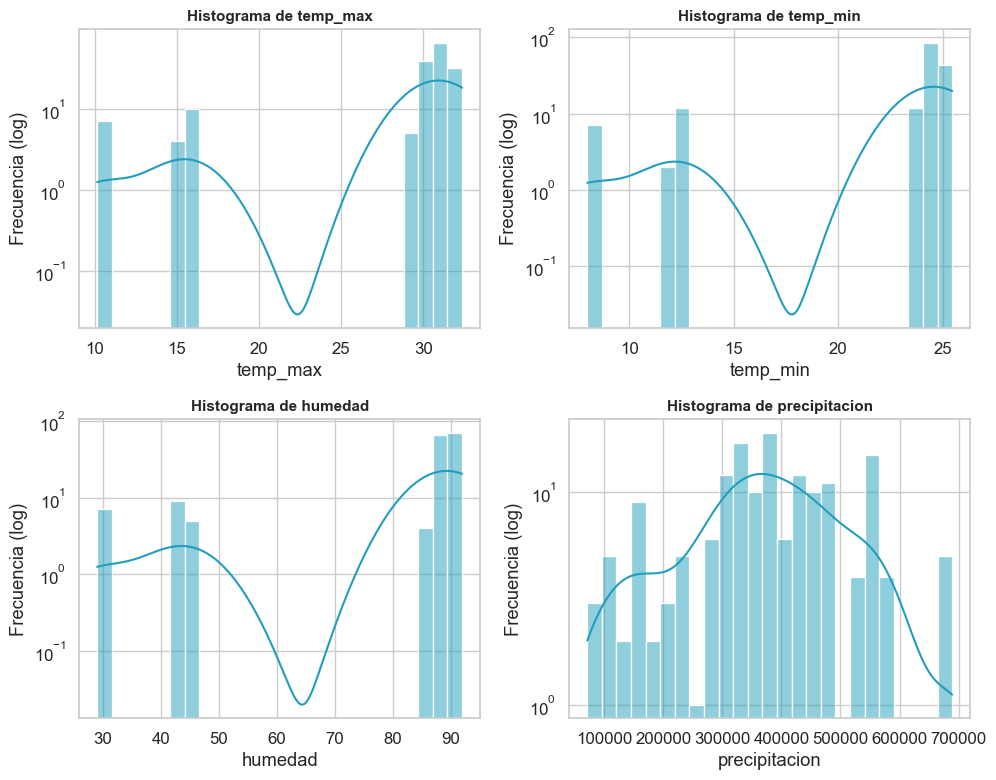

In [93]:
hist_variables(df, variables)

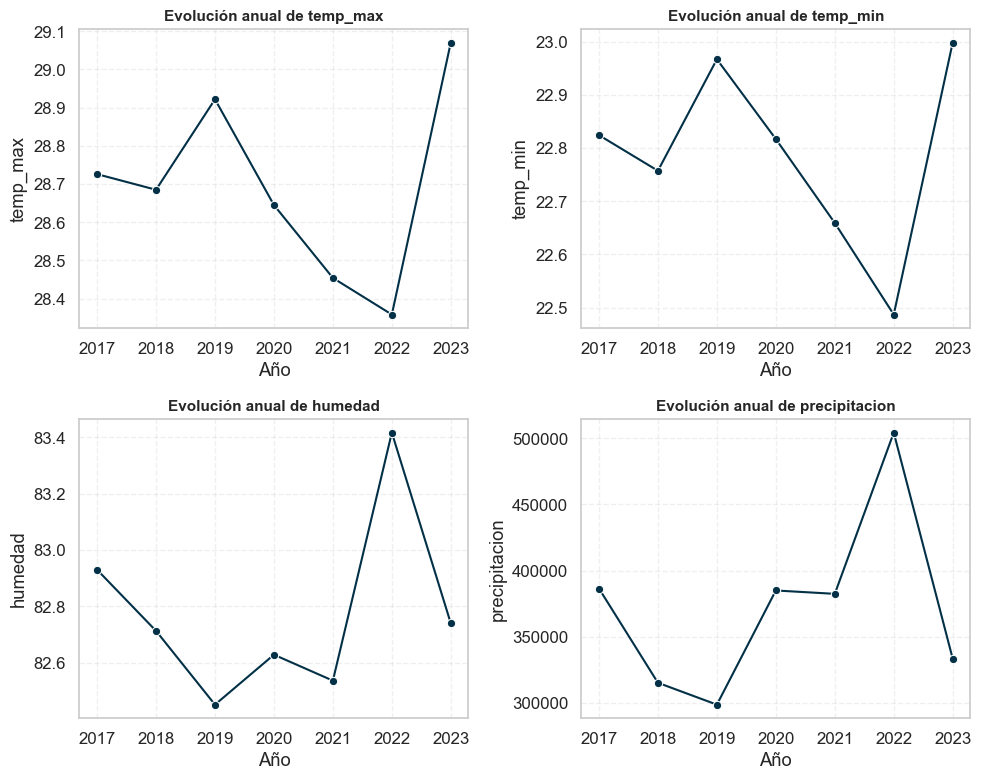

In [94]:

evolucion_anual(df, variables)

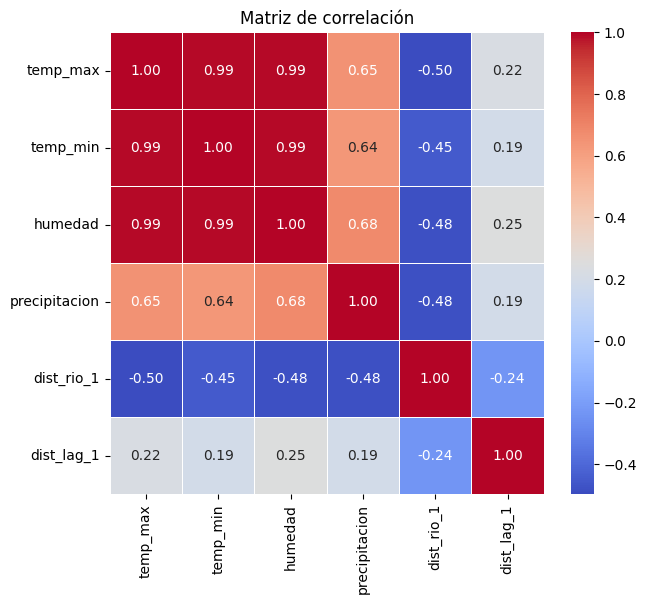

In [87]:
def matriz_correlacion(df, variables):
    corr = df[variables].corr()
    plt.figure(figsize=(7,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matriz de correlación")
    plt.show()

# Ejemplo
matriz_correlacion(df, ["temp_max", "temp_min", "humedad", "precipitacion", "dist_rio_1", "dist_lag_1"])


In [95]:
def resumen_municipios(df):
    resumen = df.groupby("municipio")[["temp_max", "temp_min", "humedad", "precipitacion"]].mean().round(2)
    resumen = resumen.sort_values("precipitacion", ascending=False)
    display(resumen)
    return resumen

resumen = resumen_municipios(df)


,temp_max,temp_min,humedad,precipitacion
municipio,,,,
Baranoa,30.41,23.97,90.85,529353.96
Palmar De Varela,31.31,24.66,89.83,529353.96
Santo Tomás,30.92,24.47,89.94,529353.96
Sabanagrande,31.05,24.78,89.13,529353.96
Polonuevo,30.92,24.47,89.94,529353.96
Ponedera,31.59,24.40,91.29,449698.17
Malambo,30.65,24.63,89.13,420023.32
Usiacurí,30.66,24.10,90.00,416644.77
Sabanalarga,31.02,24.18,90.22,416644.77
